# News-Only Politicization Score

Computes the News-Only politicization trend using **Step3's own estimator and full pipeline** —
per-subsample cosine similarity averaged across 20 subsamples, with the same subsample-weighted
uncertainty band Step3 uses — so it's directly comparable, on the same scale, to Step3's real
published results. Replicates Step3's overall trend plot (Figure 1 style) and category-level
early-vs-late-period plots (Figures 3/4), each with a News-Only vs. All-Articles comparison added.

Reads only the already-built `ALC_dems/` checkpoint (`topic_<tp>.rds` + `anchors.rds`) plus the
real saved `Results Files/ALC_ideology_results_df.rds`/`..._party_results_df.rds` for the
All-Articles comparison.

## Setup

In [1]:
library(dplyr)
library(stringr)
library(ggplot2)

dict_terms  <- readRDS("Results_Files/dict_terms_final_0510.rds")
anchor_dems <- readRDS("ALC_dems/anchors.rds")

NEWS_EXCLUDE_PATTERN <- "Commentary|Editorial|Review"


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Filter + grouping helper

**What this needs to do:** `ALC_dems/topic_<tp>.rds` stores one row per individual context window
(one occurrence of a dictionary term), tagged with which `subsample` and `Type` (news, editorial,
etc.) it came from. To get a news-only embedding for one term-year, we need to (1) drop rows whose
`Type` looks like Commentary/Editorial/Review, then (2) average what's left within each Year.

**Why per-subsample, not all at once:** Step3's own politicization score is the *average of 20
separate per-subsample estimates*, not one estimate computed from all the data pooled together
(`Step3_ALC_Embedding.ipynb`'s `compute_term_metrics`). This function is always called on one
subsample's rows at a time (the caller filters to `subsample == n` first) so that structure is
preserved.

In [2]:
group_dem_by_year_newsonly <- function(mat, docvars, exclude_pattern = NEWS_EXCLUDE_PATTERN) {

  # 1. Keep only non-opinion rows
  keep    <- !str_detect(docvars$Type, exclude_pattern)
  mat     <- mat[keep, , drop = FALSE]
  docvars <- docvars[keep, ]

  if (nrow(mat) == 0) return(NULL)  # this subsample had zero news-only contexts for this term

  # 2. Average the remaining rows within each Year: rowsum() gives the sum
  #    per Year, dividing by the count per Year turns that into a mean —
  #    the same arithmetic conText::dem_group() uses internally.
  year_sum   <- rowsum(mat, group = docvars$Year)
  year_count <- table(docvars$Year)
  sweep(year_sum, 1, as.numeric(year_count[rownames(year_sum)]), "/")
}

## Real subsample sizes (text_n)

Step3's uncertainty band weights each subsample's contribution by how many documents were in it
(`text_n`). Both `dem_topic()` (`Step3_ALC_Embedding.ipynb`) and the anchor builder
(`Step5_Close_Reading.ipynb`) already stamp the real `text_n <- subsample_sizes[n]` onto every
saved row's docvars, so we read it back from the checkpoint instead of needing the raw tokens that
originally produced it.

In [3]:
subsample_sizes <- anchor_dems$liberal$docvars %>%
  distinct(subsample, text_n) %>%
  arrange(subsample) %>%
  pull(text_n)

In [4]:
subsample_sizes

[1] 67623 67612 67380 67697 67648 67518 67455 67212 67800 67075 67867 67471
[13] 67685 67431 67348 67227 67331 67824 67490 67306

## News-only anchor embeddings, per subsample

Rebuilt from `ALC_dems/anchors.rds` — Step3's own saved anchor files (`lib_wv_subsamples.rds` etc.) aren't reusable here since they were never Type-filtered.

In [9]:
build_newsonly_anchor_wv_subsamples <- function(anchor_name) {
  ad <- anchor_dems[[anchor_name]]
  lapply(1:20, function(n) {
    sub_rows <- ad$docvars$subsample == n
    group_dem_by_year_newsonly(ad$matrix[sub_rows, , drop = FALSE], ad$docvars[sub_rows, ])
  })
}

lib_wv_subsamples_newsonly <- build_newsonly_anchor_wv_subsamples("liberal")
con_wv_subsamples_newsonly <- build_newsonly_anchor_wv_subsamples("conservative")
dem_wv_subsamples_newsonly <- build_newsonly_anchor_wv_subsamples("democrat")
rep_wv_subsamples_newsonly <- build_newsonly_anchor_wv_subsamples("republican")

## Metrics functions

Same structure as Step3's `compute_term_metrics`/`compute_party_metrics`: loop over the 20
subsamples, get one cosine similarity per subsample, then summarise across subsamples into a mean
plus an uncertainty band. The **only** change from Step3's originals is swapping the year-grouping
step for the news-only-filtered version above — everything else (the `error_lib`/`error_con`
weighting, the quantile-based CI) is identical, which is what makes `cos_liberal_lower`/`upper`
here comparable to Step3's own CI columns.

In [5]:
compute_term_metrics_newsonly <- function(t, term_data) {

  years   <- as.character(1980:2024)
  results <- list()

  for (n in 1:20) {

    sub_rows <- term_data$docvars$subsample == n
    term_wv  <- group_dem_by_year_newsonly(term_data$matrix[sub_rows, , drop = FALSE],
                                            term_data$docvars[sub_rows, ])

    lib_wv <- lib_wv_subsamples_newsonly[[n]]
    con_wv <- con_wv_subsamples_newsonly[[n]]

    for (year in years) {

      # term_wv/lib_wv/con_wv can be NULL if that subsample had zero
      # news-only contexts for this term/anchor in any year — skip those.
      year_present <- !is.null(term_wv) && !is.null(lib_wv) && !is.null(con_wv) &&
                       year %in% rownames(term_wv) &&
                       year %in% rownames(lib_wv)  &&
                       year %in% rownames(con_wv)

      if (year_present) {
        avg_emb <- term_wv[year, ]
        cos_lib <- as.numeric(lsa::cosine(lib_wv[year, ], avg_emb))
        cos_con <- as.numeric(lsa::cosine(con_wv[year, ], avg_emb))
      } else {
        cos_lib <- NA
        cos_con <- NA
      }

      results[[length(results) + 1]] <- data.frame(
        term        = t,
        year        = as.integer(year),
        subsample   = n,
        text_n      = subsample_sizes[n],
        cos_liberal = cos_lib,
        cos_con     = cos_con
      )
    }
  }

  # Same subsample-weighted uncertainty band as Step3_ALC_Embedding.ipynb's
  # compute_term_metrics(): larger subsamples get more weight, and the CI is
  # the 5th/95th percentile of that weighted deviation from the mean.
  do.call(rbind, results) %>%
    group_by(term, year) %>%
    mutate(
      cos_liberal_avg = mean(cos_liberal, na.rm = TRUE),
      cos_con_avg     = mean(cos_con,     na.rm = TRUE),
      error_lib = sqrt(text_n) * (cos_liberal - cos_liberal_avg) / sqrt(1350000),
      error_con = sqrt(text_n) * (cos_con     - cos_con_avg)     / sqrt(1350000)
    ) %>%
    summarise(
      cos_liberal_mean  = mean(cos_liberal, na.rm = TRUE),
      cos_liberal_lower = cos_liberal_mean - quantile(error_lib, 0.95, na.rm = TRUE),
      cos_liberal_upper = cos_liberal_mean - quantile(error_lib, 0.05, na.rm = TRUE),
      cos_con_mean      = mean(cos_con,     na.rm = TRUE),
      cos_con_lower     = cos_con_mean - quantile(error_con, 0.95, na.rm = TRUE),
      cos_con_upper     = cos_con_mean - quantile(error_con, 0.05, na.rm = TRUE),
      .groups = "drop"
    )
}

In [6]:
compute_party_metrics_newsonly <- function(t, term_data) {

  years   <- as.character(1980:2024)
  results <- list()

  for (n in 1:20) {

    sub_rows <- term_data$docvars$subsample == n
    term_wv  <- group_dem_by_year_newsonly(term_data$matrix[sub_rows, , drop = FALSE],
                                            term_data$docvars[sub_rows, ])

    dem_wv <- dem_wv_subsamples_newsonly[[n]]
    rep_wv <- rep_wv_subsamples_newsonly[[n]]

    for (year in years) {

      year_present <- !is.null(term_wv) && !is.null(dem_wv) && !is.null(rep_wv) &&
                       year %in% rownames(term_wv) &&
                       year %in% rownames(dem_wv)  &&
                       year %in% rownames(rep_wv)

      if (year_present) {
        avg_emb <- term_wv[year, ]
        cos_dem <- as.numeric(lsa::cosine(dem_wv[year, ], avg_emb))
        cos_rep <- as.numeric(lsa::cosine(rep_wv[year, ], avg_emb))
      } else {
        cos_dem <- NA
        cos_rep <- NA
      }

      results[[length(results) + 1]] <- data.frame(
        term      = t,
        year      = as.integer(year),
        subsample = n,
        text_n    = subsample_sizes[n],
        cos_dem   = cos_dem,
        cos_rep   = cos_rep
      )
    }
  }

  do.call(rbind, results) %>%
    group_by(term, year) %>%
    mutate(
      cos_dem_avg = mean(cos_dem, na.rm = TRUE),
      cos_rep_avg = mean(cos_rep, na.rm = TRUE),
      error_dem = sqrt(text_n) * (cos_dem - cos_dem_avg) / sqrt(1350000),
      error_rep = sqrt(text_n) * (cos_rep - cos_rep_avg) / sqrt(1350000)
    ) %>%
    summarise(
      cos_dem_mean  = mean(cos_dem, na.rm = TRUE),
      cos_dem_lower = cos_dem_mean - quantile(error_dem, 0.95, na.rm = TRUE),
      cos_dem_upper = cos_dem_mean - quantile(error_dem, 0.05, na.rm = TRUE),
      cos_rep_mean  = mean(cos_rep, na.rm = TRUE),
      cos_rep_lower = cos_rep_mean - quantile(error_rep, 0.95, na.rm = TRUE),
      cos_rep_upper = cos_rep_mean - quantile(error_rep, 0.05, na.rm = TRUE),
      .groups = "drop"
    )
}

## Driver — all topics

In [7]:
newsonly_topics <- unique(dict_terms$topic)
newsonly_topics <- newsonly_topics[sapply(newsonly_topics, function(tp)
  file.exists(paste0("ALC_dems/topic_", tp, ".rds")))]

length(newsonly_topics)

[1] 133

In [ ]:
results_df_newsonly <- do.call(rbind, lapply(newsonly_topics, function(tp) {
  topic_terms <- subset(dict_terms, topic == tp)$term
  term_dems   <- readRDS(paste0("ALC_dems/topic_", tp, ".rds"))
  message("Processing topic (ideology, news-only): ", tp)
  do.call(rbind, lapply(topic_terms, function(term) compute_term_metrics_newsonly(term, term_dems[[term]])))
}))

results_df_party_newsonly <- do.call(rbind, lapply(newsonly_topics, function(tp) {
  topic_terms <- subset(dict_terms, topic == tp)$term
  term_dems   <- readRDS(paste0("ALC_dems/topic_", tp, ".rds"))
  message("Processing topic (party, news-only): ", tp)
  do.call(rbind, lapply(topic_terms, function(term) compute_party_metrics_newsonly(term, term_dems[[term]])))
}))

head(results_df_newsonly)

Processing topic (ideology, news-only): 1

Processing topic (ideology, news-only): 2

Processing topic (ideology, news-only): 4

Processing topic (ideology, news-only): 5

Processing topic (ideology, news-only): 9

Processing topic (ideology, news-only): 10

Processing topic (ideology, news-only): 13

Processing topic (ideology, news-only): 14

Processing topic (ideology, news-only): 16

Processing topic (ideology, news-only): 17

Processing topic (ideology, news-only): 20

Processing topic (ideology, news-only): 21

Processing topic (ideology, news-only): 23

Processing topic (ideology, news-only): 25

Processing topic (ideology, news-only): 29

Processing topic (ideology, news-only): 30

Processing topic (ideology, news-only): 33

Processing topic (ideology, news-only): 39

Processing topic (ideology, news-only): 43

Processing topic (ideology, news-only): 46

Processing topic (ideology, news-only): 49

Processing topic (ideology, news-only): 52

Processing topic (ideology, news-only

Processing topic (party, news-only): 147

Processing topic (party, news-only): 149

Processing topic (party, news-only): 150

Processing topic (party, news-only): 152

Processing topic (party, news-only): 153

Processing topic (party, news-only): 162

Processing topic (party, news-only): 165

Processing topic (party, news-only): 169

Processing topic (party, news-only): 170

Processing topic (party, news-only): 171

Processing topic (party, news-only): 172

Processing topic (party, news-only): 174

Processing topic (party, news-only): 176

Processing topic (party, news-only): 177

Processing topic (party, news-only): 182

Processing topic (party, news-only): 185

Processing topic (party, news-only): 186

Processing topic (party, news-only): 188

Processing topic (party, news-only): 189

Processing topic (party, news-only): 192

Processing topic (party, news-only): 197

Processing topic (party, news-only): 198

Processing topic (party, news-only): 201

Processing topic (party, news-only

## Merge with dict_terms + frequency, compute politicization score

Reuses the cached `freq_by_year_source.rds`, aggregated by `(term, year)` only — pooled across
outlets, matching how Step3 itself merges frequency. `pol_score`/`pol_score_upper`/
`pol_score_lower` and the final column selection exactly mirror `Step3_ALC_Embedding.ipynb`'s
politicization-score cell, so `results_df_cat_newsonly` below has the identical shape Step3's own
`results_df_cat` does.

In [ ]:
freq_by_year <- readRDS("freq_by_year_source.rds") %>%
  group_by(term, Year) %>%
  summarise(frequency = sum(frequency, na.rm = TRUE), .groups = "drop") %>%
  rename(year = Year) %>%
  mutate(year = as.numeric(year))

results_df_newsonly <- results_df_newsonly %>%
  left_join(dict_terms, by = "term") %>%
  filter(!is.na(label)) %>%
  left_join(freq_by_year, by = c("term", "year")) %>%
  filter(frequency >= 10) %>%
  mutate(pol_score       = (cos_liberal_mean  + cos_con_mean)  / 2,
         pol_score_upper = (cos_liberal_upper + cos_con_upper) / 2,
         pol_score_lower = (cos_liberal_lower + cos_con_lower) / 2,
         group = "ideology") %>%
  select(term, year, topic, label, pol_score, pol_score_upper, pol_score_lower, group)

results_df_party_newsonly <- results_df_party_newsonly %>%
  left_join(dict_terms, by = "term") %>%
  filter(!is.na(label)) %>%
  left_join(freq_by_year, by = c("term", "year")) %>%
  filter(frequency >= 10) %>%
  mutate(pol_score       = (cos_dem_mean  + cos_rep_mean)  / 2,
         pol_score_upper = (cos_dem_upper + cos_rep_upper) / 2,
         pol_score_lower = (cos_dem_lower + cos_rep_lower) / 2,
         group = "party") %>%
  select(term, year, topic, label, pol_score, pol_score_upper, pol_score_lower, group)

saveRDS(results_df_newsonly,       "Results_Files/ALC_ideology_results_df_newsonly.rds")
saveRDS(results_df_party_newsonly, "Results_Files/ALC_party_results_df_newsonly.rds")

## Load the real All-Articles results, processed the same way

For a fair comparison, apply the exact same politicization-score formula to the real saved Step3 output (no recomputation — just the same downstream transform applied to both).

In [12]:
results_df_original <- readRDS("Results_Files/ALC_ideology_results_df.rds") %>%
  filter(frequency >= 10) %>%
  mutate(pol_score       = (cos_liberal_mean  + cos_con_mean)  / 2,
         pol_score_upper = (cos_liberal_upper + cos_con_upper) / 2,
         pol_score_lower = (cos_liberal_lower + cos_con_lower) / 2,
         group = "ideology") %>%
  select(term, year, topic, label, pol_score, pol_score_upper, pol_score_lower, group)

results_df_party_original <- readRDS("Results_Files/ALC_party_results_df.rds") %>%
  filter(frequency >= 10) %>%
  mutate(pol_score       = (cos_dem_mean  + cos_rep_mean)  / 2,
         pol_score_upper = (cos_dem_upper + cos_rep_upper) / 2,
         pol_score_lower = (cos_dem_lower + cos_rep_lower) / 2,
         group = "party") %>%
  select(term, year, topic, label, pol_score, pol_score_upper, pol_score_lower, group)

## Category mapping

`Step3_ALC_Embedding.ipynb`'s exact `case_when` block, applied identically to both corpora.

In [13]:
assign_category <- function(df) {
  df %>%
    mutate(Category = case_when(
      label %in% c("Abortion", "Gender", "LGBTQ", "Marriage", "Parenting") ~ "Gender and Family",
      label %in% c("Catholicism", "Religion") ~ "Religion",
      label %in% c("Minority", "Native_American", "Racial", "Confederate", "Immigration") ~ "Race and Immigration",
      label %in% c("Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections") ~ "Politics",
      label %in% c("CriminalJustice", "Investigation", "Criminal", "Burglary", 
                   "Homicide", "Police") ~ "Crime and Policing",
      label %in% c("Constitution_Law", "Judicial", "Lawsuit", "SupremeCourt") ~ "Legal Institution",
      label %in% c("Higher_Education", "Education") ~ "Education",
      label %in% c("Science") ~ "Science",
      label %in% c("Gun_Control") ~ "Gun",
      label %in% c("Bankruptcy", "Banks", "Commodity_Market", "Corporate", "CorporateFinance",
                   "Earnings", "ExecutiveCompensation", "Financial", "Investing", "Money_Markets",
                   "Retail", "Securities",
                   "Stock_market", "Foreign_exchange") ~ "Financial Market",
      label %in% c("Welfare & Poverty", "Taxation", "Economics", "Agriculture", "Business",
                   "Economy", "Fiscal", "Labor", "Workers", "MonetaryPolicy", "Trade") ~ "Economic Issues",
      label %in% c("Housing", "Urban_development", "Mortgage", "Architecture") ~ "Housing",
      label %in% c("China", "Espionage", "Latin_America", "Middle_East",
                   "MiddleEastConflict", "Military", "NuclearArms", "Terrorism", "Russia & Ukraine") ~ "Foreign Affairs",
      label %in% c("ClimateChange", "Disaster", "Air Pollution",
                   "Weather", "Wildfires") ~ "Environment",
      label %in% c("Healthcare", "Hospital", "MentalHealth", "Nutrition", "Pharmaceuticals",
                   "Substance Abuse", "Vaccine", "Disease") ~ "Health",
      label %in% c("Art",  "Broadway",  "Classical_Music", 
                      "Museum", "Fashion", 
                      "Literature", "Movie", "Music") ~ "Creative Arts",
      label %in% c("Festival", "TravelIndustry", "Horticulture", "Nature", "Gaming") ~ "Leisure",
      label %in% c("Culinary", "Dining",  "Wine", "Beverage") ~ "Food & Drinks",
      label %in% c("Journalism", "Radio", "Television", "TV_Entertainment") ~ "Media",
      label %in% c("AmericanFootball", "Baseball", "NBA", "NFL", "Boxing",
                   "CollegeSports", "Golf", "NHL", "Soccer",  "Tennis") ~ "Sports",
      label %in% c("Electricity", "Energy", "Postal_service",  "Telecommunications", "Water") ~ "Infrastructure",
      label %in% c("Maritime",  "Mass_Transit", "Airline", "Automotive",
                    "Railroad", "Traffic", "Transportation") ~ "Transportation",
      label %in% c("Animal", "Marine_Biology",  "Wildlife") ~ "Animals",
      label %in% c("Home", "Household", "Cooking") ~ "Home",
      label == "Space" ~ "Outer Space",
      TRUE ~ "Other"))
}

results_df_cat_newsonly <- assign_category(rbind(results_df_newsonly, results_df_party_newsonly)) %>%
  mutate(Corpus = "News-Only")

results_df_cat_original <- assign_category(rbind(results_df_original, results_df_party_original)) %>%
  mutate(Corpus = "All Articles")

results_df_cat_combined <- rbind(results_df_cat_original, results_df_cat_newsonly)

## Overall trend (comparable to Step3's Figure 1)

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


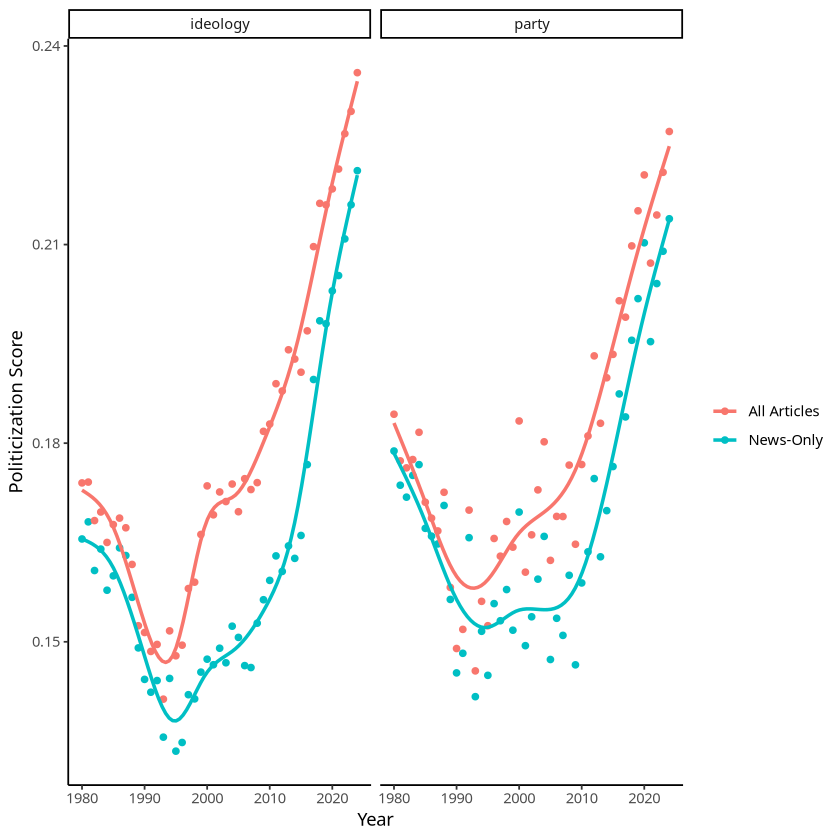

In [17]:
results_df_cat_combined %>%
    group_by(year, group, Corpus) %>%
    summarise(value_avg = mean(pol_score, na.rm = TRUE), .groups = "drop") %>%
    ggplot(aes(x = year, y = value_avg, color = Corpus)) +
    geom_point() +
    geom_smooth(method = "gam", se = FALSE) +
    facet_wrap(~ group) +
    theme_classic() +
    labs(x = "Year", y = "Politicization Score") +
    guides(color = guide_legend(title = ""))

In [18]:
ggsave("pol_trend_compare.png", width = 10)

Saving 10 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


## Category-level early vs. late period (Figures 3/4)

Same construction as `Step3_ALC_Embedding.ipynb` cells 61/69/71/73: average `pol_score` (with its
CI) by Category for 1980-1989 ("early") vs. 2015-2024 ("late"), one dot+errorbar pair per Category.
Faceted by `Corpus` here so All-Articles and News-Only sit side by side for direct comparison.

In [14]:
category_year <- results_df_cat_combined %>%
  group_by(year, Category, group, Corpus) %>%
  summarise(
    value_avg   = mean(pol_score,       na.rm = TRUE),
    value_upper = mean(pol_score_upper, na.rm = TRUE),
    value_lower = mean(pol_score_lower, na.rm = TRUE),
    .groups = "drop"
  )

category_period <- category_year %>%
  group_by(Category, group, Corpus) %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE),
    .groups = "drop"
  )

head(category_period)

Category,group,Corpus,late_value,late_upper,late_lower,early_value,early_upper,early_lower
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Animals,ideology,All Articles,0.1948574,0.2184437,0.1704906,0.1600330,0.1842646,0.1351500
Animals,ideology,News-Only,0.1779565,0.2015759,0.1535536,0.1543644,0.1786224,0.1295101
Animals,party,All Articles,0.1885538,0.2104089,0.1658941,0.1633997,0.1861462,0.1400824
Animals,party,News-Only,0.1758286,0.1977215,0.1531186,0.1602682,0.1830762,0.1370572
Creative Arts,ideology,All Articles,0.2094041,0.2310977,0.1874977,0.1737228,0.1974619,0.1495504
Creative Arts,ideology,News-Only,0.1883998,0.2105193,0.1659679,0.1603946,0.1842088,0.1360300


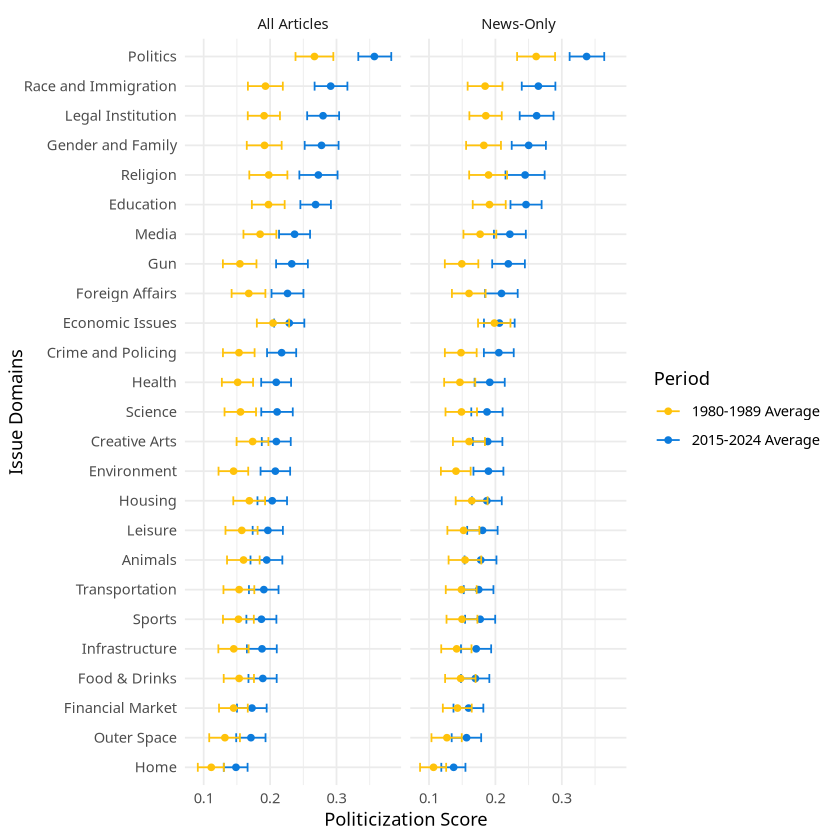

In [30]:
## Figure 3 style — ideology
category_period %>%
  filter(group == "ideology") %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper, color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper, color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  facet_wrap(~ Corpus) +
  labs(x = "Politicization Score", y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11)

In [31]:
ggsave("politicization_ideo_newsonly.png", width =6.5, height = 7)

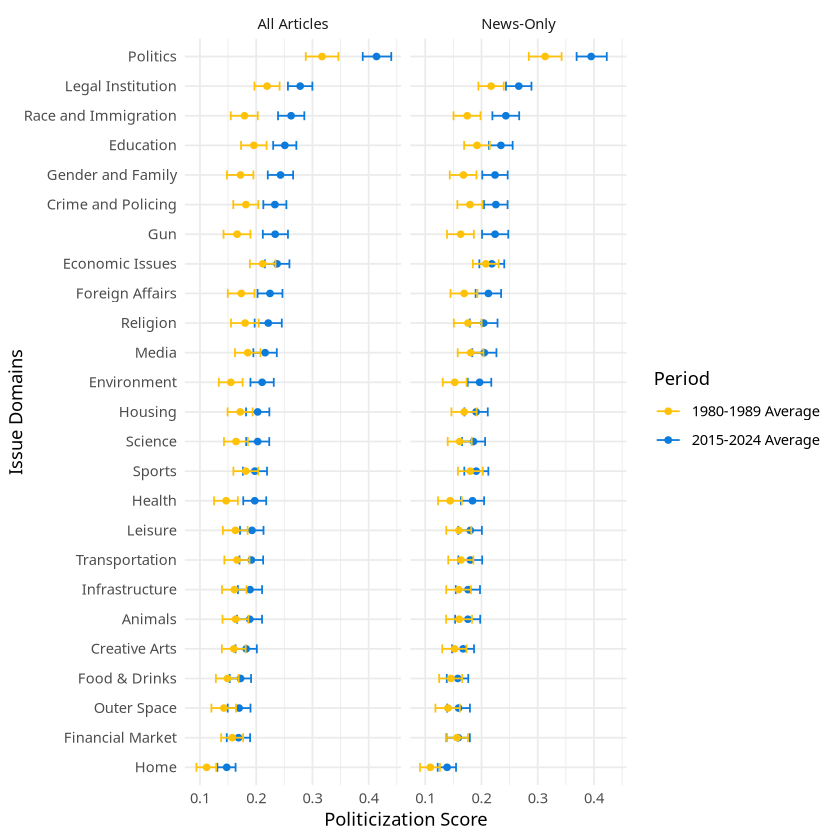

In [32]:
## Figure 4 style — party
category_period %>%
  filter(group == "party") %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper, color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper, color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  facet_wrap(~ Corpus) +
  labs(x = "Politicization Score", y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11)

In [33]:
ggsave("politicization_party_newsonly.png", width =6.5, height = 7)

In [25]:
library(tidyr)

## rank 1 = most politicized (highest score) within that Corpus
compare_rank_order <- function(period_data, value_col, g) {
  ranked <- period_data %>%
    filter(group == g) %>%
    select(Category, Corpus, value = all_of(value_col)) %>%
    group_by(Corpus) %>%
    mutate(rank = rank(-value)) %>%
    ungroup() %>%
    select(-value) %>%
    pivot_wider(names_from = Corpus, values_from = rank) %>%
    mutate(rank_diff = abs(`All Articles` - `News-Only`)) %>%
    arrange(desc(rank_diff))

  list(
    spearman_rho = cor(ranked$`All Articles`, ranked$`News-Only`, method = "spearman"),
    table = ranked
  )
}

In [26]:
rank_ideo_late <- compare_rank_order(category_period, "late_value", "ideology")
rank_ideo_late$spearman_rho   # 1 = ranks identical, 0 = no relationship, -1 = fully reversed
rank_ideo_late$table          # sorted by biggest rank movers first

[1] 0.9861538

Category,All Articles,News-Only,rank_diff
<chr>,<dbl>,<dbl>,<dbl>
Science,12,15,3
Sports,22,19,3
Environment,15,13,2
Food & Drinks,20,22,2
Health,14,12,2
Creative Arts,13,14,1
Economic Issues,9,10,1
Education,6,5,1
Foreign Affairs,10,9,1


In [27]:
rank_party_late <- compare_rank_order(category_period, "late_value", "party")
rank_party_late$spearman_rho
rank_party_late$table

[1] 0.9869231

Category,All Articles,News-Only,rank_diff
<chr>,<dbl>,<dbl>,<dbl>
Crime and Policing,8,5,3
Economic Issues,6,8,2
Food & Drinks,22,24,2
Gender and Family,5,7,2
Sports,15,13,2
Financial Market,24,23,1
Gun,7,6,1
Housing,13,14,1
Leisure,17,18,1


## Shrinkage diagnostic: how much does the news-only filter remove per subsample?

In [19]:
anchor_dems$liberal$docvars %>%
  group_by(subsample) %>%
  summarise(
    total     = n(),
    news_only = sum(!str_detect(Type, NEWS_EXCLUDE_PATTERN)),
    pct_kept  = round(news_only / total, 3),
    .groups = "drop"
  )

subsample,total,news_only,pct_kept
<int>,<int>,<int>,<dbl>
1,2426,1746,0.720
2,2601,1758,0.676
3,2570,1799,0.700
4,2604,1876,0.720
5,2590,1838,0.710
6,2520,1820,0.722
7,2497,1750,0.701
8,2557,1799,0.704
9,2641,1863,0.705


In [20]:
anchor_shrinkage <- sapply(anchor_dems, function(ad) {
  total     <- nrow(ad$docvars)
  news_only <- sum(!str_detect(ad$docvars$Type, NEWS_EXCLUDE_PATTERN))
  c(total = total, news_only = news_only, pct_kept = round(news_only / total, 3))
})
t(anchor_shrinkage)

,total,news_only,pct_kept
liberal,51274,36149,0.705
conservative,95872,76791,0.801
democrat,239196,197787,0.827
republican,333852,275675,0.826
